# Exploratory analysis of timing and resource distributions
### by Jiachen Cong
## In this code, I have finished following analysis
### 1) Waiting time distribution (Start - Submit)
### 2) Submission patterns by weekday and hour of day
### 3) Runtime distribution (End - Start) for completed jobs
### 4) Resource request distributions: ReqCPUS, ReqMem, ReqNodes
### 5）Resource request distributions: Required GPUs
### 6) Is there a significant difwference in the waiting time between tasks that use only the CPU and those that require a GPU?
#### My main idea for this part is to extract as much information/patterns as possible from our data.
#### The data and code can be found at box. This code uses data set "master_2025_joblevel_submission.csv.gz" and "master_2025_joblevel_terminal.csv.gz". You just need to put this code with those data set in the same folder.

In [1]:
# loading necessary packages
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# loading data
ROOT = Path.cwd()
SUB_PATH = ROOT / "master_2025_joblevel_submission.csv.gz"
TER_PATH = ROOT / "master_2025_joblevel_terminal.csv.gz"

assert SUB_PATH.exists(), f"Missing: {SUB_PATH}"
assert TER_PATH.exists(), f"Missing: {TER_PATH}"

# load the data
sub = pd.read_csv(SUB_PATH, compression="gzip")
ter = pd.read_csv(TER_PATH, compression="gzip")

# print the name of columns
print("Columns in sub:")
print(sub.columns.tolist())

print("\nColumns in ter:")
print(ter.columns.tolist())

# Count the number of tasks in different states
print(ter["State"].value_counts())

Columns in sub:
['JobIDRaw', 'User', 'Group', 'Account', 'Partition', 'QOS', 'Submit', 'State', 'Priority', 'ReqCPUS', 'ReqMem_MB', 'ReqNodes', 'ReqTRES', 'TimelimitRaw', 'AllocCPUS', 'AllocNodes']

Columns in ter:
['JobIDRaw', 'User', 'Group', 'Account', 'Partition', 'QOS', 'Submit', 'Eligible', 'State', 'Priority', 'ReqCPUS', 'ReqMem_MB', 'ReqNodes', 'ReqTRES', 'AllocCPUS', 'AllocNodes', 'Start', 'End', 'ElapsedRaw', 'TimelimitRaw', 'ExitCode', 'Reason', 'WaitTimeSec', 'RunTimeSec']
State
COMPLETED        4640994
CANCELLED         639013
FAILED            585112
TIMEOUT           116146
OUT_OF_MEMORY      43313
PENDING              515
NODE_FAIL            218
REQUEUED              13
RUNNING                2
Name: count, dtype: int64


### Convert timestamp columns to datetime format
### The raw CSV files store Submit, Start, and End as strings.
### I convert them to pandas datetime objects so that we can:
####   1) Compute time differences (e.g., Start - Submit)
####   2) Extract hour / weekday information
####  3) Perform proper time-based analysis
#### errors="coerce" ensures that invalid timestamps are safely converted to NaT instead of raising an exception.
#### I do this in both data sets mentioned above.

In [2]:
for df in (sub, ter):
    for c in ["Submit", "Start", "End"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

### Ensure numeric resource and duration columns are numeric
### Although these columns represent numbers (CPUs, memory, time), they may be loaded as strings from the CSV.
### We explicitly convert them to numeric types so that:
#### 1) Summary statistics (mean, percentiles) are correct
#### 2) Histograms and other plots work properly
#### 3) Arithmetic operations are valid
#### errors="coerce" converts invalid entries to NaN instead of failing.
#### I do this in both data sets mentioned above.

In [3]:
for df in (sub, ter):
    for c in ["ReqCPUS", "ReqNodes", "AllocCPUS", "AllocNodes", "ReqMem_MB", "WaitTimeSec", "RunTimeSec"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

print("submission shape:", sub.shape)
print("terminal shape:  ", ter.shape)

submission shape: (6025326, 16)
terminal shape:   (6025326, 24)


## Q1: Wait time distribution (Start - Submit)
### IMPORTANT: I use the terminal table ("master_2025_joblevel_terminal.csv.gz"), since it has Start/End and WaitTimeSec.
### Not included: tasks in PENDING status; some tasks in CANCELLED status (tasks cancelled and not started)


=== Wait time (hours) summary ===
count    5.517282e+06
mean     6.953498e+00
std      3.126922e+01
min      0.000000e+00
50%      4.230556e-01
90%      1.300886e+01
95%      3.112944e+01
99%      1.160972e+02
max      6.865697e+03
Name: WaitTimeSec, dtype: float64


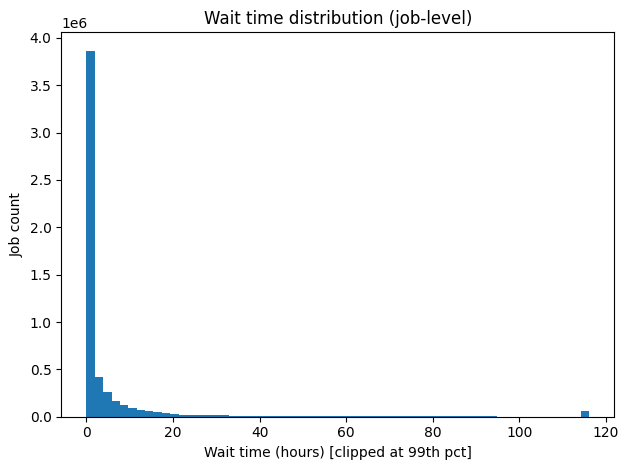

In [4]:
if "WaitTimeSec" in ter.columns:
    wait = ter["WaitTimeSec"]
else:
    # compute from timestamps if needed
    wait = (ter["Start"] - ter["Submit"]).dt.total_seconds()

wait = wait.replace([np.inf, -np.inf], np.nan).dropna()
wait_hr = wait / 3600.0

print("\n=== Wait time (hours) summary ===")
print(wait_hr.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
plt.hist(wait_hr.clip(upper=np.nanpercentile(wait_hr, 99)), bins=60)
plt.xlabel("Wait time (hours) [clipped at 99th pct]")
plt.ylabel("Job count")
plt.title("Wait time distribution (job-level)")
plt.tight_layout()
plt.show()

## Q2: Submission patterns by weekday and hour of day
#### In this section, I use the data set "master_2025_joblevel_submission.csv.gz".


=== Submissions by weekday ===
SubmitWeekday
Monday       864472
Tuesday      969666
Wednesday    837331
Thursday     814956
Friday       855459
Saturday     816110
Sunday       867332
Name: count, dtype: int64

=== Submissions by hour (0-23) ===
SubmitHour
0     271256
1     240464
2     220156
3     139365
4     123713
5     127304
6     137256
7     143170
8     179919
9     190417
10    276210
11    300606
12    295872
13    279835
14    304868
15    377099
16    359670
17    322188
18    294654
19    256135
20    244337
21    282626
22    350138
23    308068
Name: count, dtype: int64


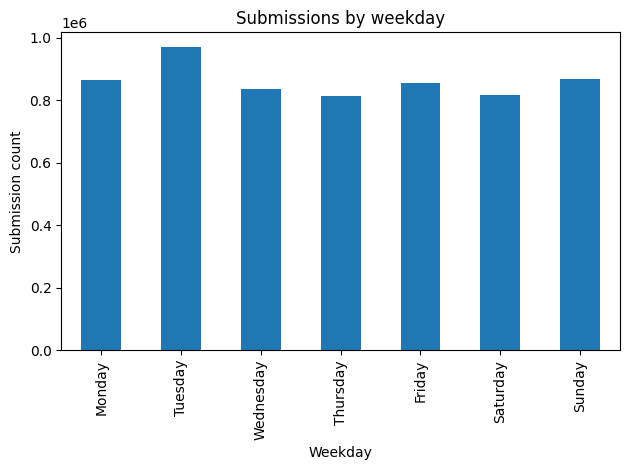

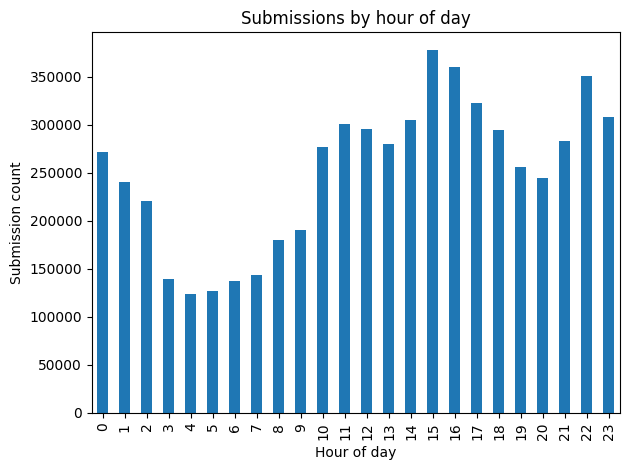

In [5]:
sub["SubmitHour"] = sub["Submit"].dt.hour
sub["SubmitWeekday"] = sub["Submit"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sub["SubmitWeekday"] = pd.Categorical(sub["SubmitWeekday"], categories=weekday_order, ordered=True)

weekday_counts = sub["SubmitWeekday"].value_counts().reindex(weekday_order)
hour_counts = sub["SubmitHour"].value_counts().sort_index()

print("\n=== Submissions by weekday ===")
print(weekday_counts)

print("\n=== Submissions by hour (0-23) ===")
print(hour_counts)

# Chart of Submissions by weekday (e.g., how many submission on monday, etc)
plt.figure()
weekday_counts.plot(kind="bar")
plt.xlabel("Weekday")
plt.ylabel("Submission count")
plt.title("Submissions by weekday")
plt.tight_layout()
plt.show()

# Chart of Submissions by hour of day (e.g., how many submission on 1 A.M., etc)
plt.figure()
hour_counts.plot(kind="bar")
plt.xlabel("Hour of day")
plt.ylabel("Submission count")
plt.title("Submissions by hour of day")
plt.tight_layout()
plt.show()

## Q3: Runtime distribution (End - Start) for completed jobs
### IMPORTANT: In this section, I only summarize the running time for COMPLETED tasks. Since only these finished tasks have recorded start and end time.
#### The unit of runtime is hours.

Negative runtime count: 20 / 4,640,994 (0.000431%)

=== Runtime (COMPLETED only, hours) summary (after removing negative) ===
count    4.640974e+06
mean     5.589862e-01
std      3.363071e+00
min      0.000000e+00
50%      1.916667e-02
90%      1.058889e+00
95%      1.945653e+00
99%      1.039793e+01
max      6.271161e+02
Name: RunTimeSec, dtype: float64


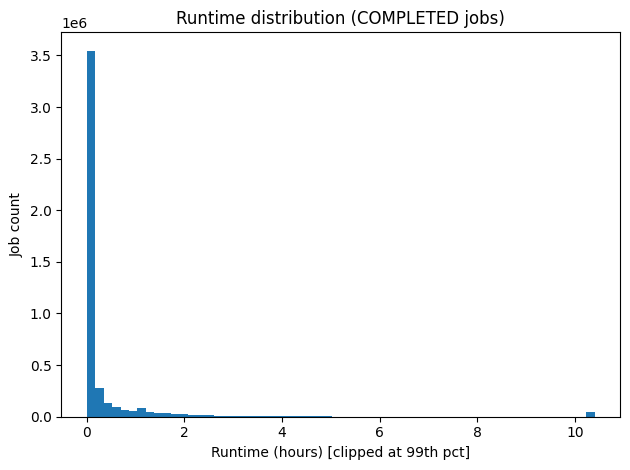

In [6]:
ter["State"] = ter["State"].astype(str).str.upper().str.strip()
completed = ter[ter["State"] == "COMPLETED"].copy()

# Compute runtime (prefer using the precomputed RunTimeSec from the data cleaning stage if available)
if "RunTimeSec" in completed.columns:
    runtime = completed["RunTimeSec"]
else:
    runtime = (completed["End"] - completed["Start"]).dt.total_seconds()

# # Clean the data: remove inf values and set impossible negative runtime values to missing
runtime = runtime.replace([np.inf, -np.inf], np.nan)

neg_cnt = (runtime < 0).sum()
valid_cnt = runtime.notna().sum()
print(f"Negative runtime count: {neg_cnt:,} / {valid_cnt:,} ({neg_cnt/valid_cnt:.6%})")

runtime = runtime.mask(runtime < 0, np.nan).dropna()
runtime_hr = runtime / 3600.0

print("\n=== Runtime (COMPLETED only, hours) summary (after removing negative) ===")
print(runtime_hr.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
plt.hist(runtime_hr.clip(upper=np.nanpercentile(runtime_hr, 99)), bins=60)
plt.xlabel("Runtime (hours) [clipped at 99th pct]")
plt.ylabel("Job count")
plt.title("Runtime distribution (COMPLETED jobs)")
plt.tight_layout()
plt.show()

## Q4: Resource request distributions: ReqCPUS, ReqMem, ReqNodes
####


=== ReqCPUS summary ===
count    6.025326e+06
mean     8.409819e+00
std      1.830992e+01
min      0.000000e+00
50%      4.000000e+00
90%      1.600000e+01
95%      2.800000e+01
99%      8.000000e+01
max      8.192000e+03
Name: ReqCPUS, dtype: float64

=== ReqNodes summary ===
count    6.025326e+06
mean     1.014275e+00
std      1.750785e-01
min      0.000000e+00
50%      1.000000e+00
90%      1.000000e+00
95%      1.000000e+00
99%      2.000000e+00
max      3.500000e+01
Name: ReqNodes, dtype: float64

=== ReqMem (GB) summary ===
count    6.025325e+06
mean     5.296862e+01
std      3.188396e+02
min      9.765625e-04
50%      1.600000e+01
90%      1.250000e+02
95%      1.804375e+02
99%      4.534180e+02
max      5.555500e+05
Name: ReqMem_MB, dtype: float64


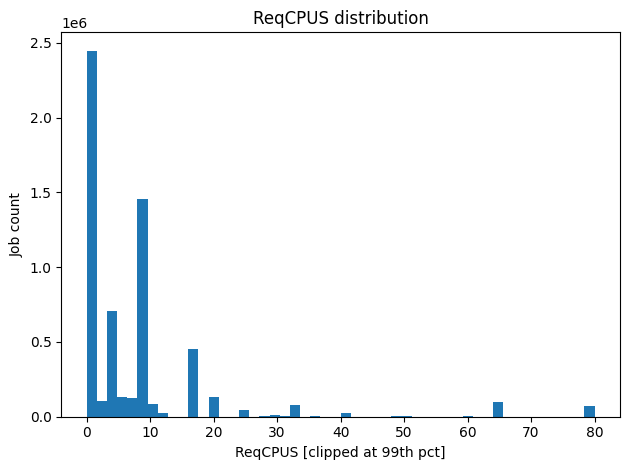

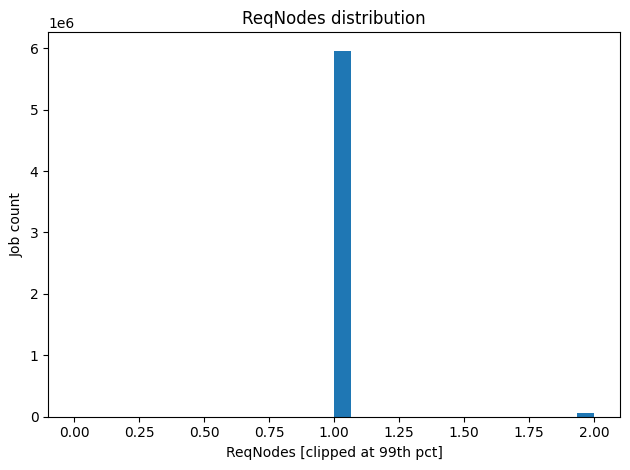

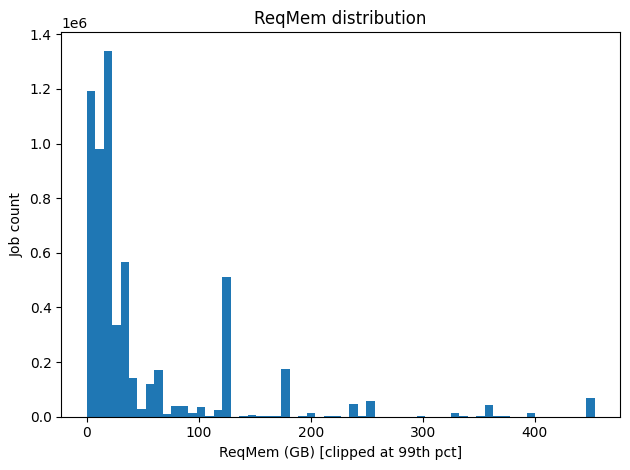

In [7]:
reqcpus = sub["ReqCPUS"].replace([np.inf, -np.inf], np.nan).dropna()
reqnodes = sub["ReqNodes"].replace([np.inf, -np.inf], np.nan).dropna()
reqmem_gb = (sub["ReqMem_MB"].replace([np.inf, -np.inf], np.nan).dropna()) / 1024.0

print("\n=== ReqCPUS summary ===")
print(reqcpus.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

print("\n=== ReqNodes summary ===")
print(reqnodes.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

print("\n=== ReqMem (GB) summary ===")
print(reqmem_gb.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
plt.hist(reqcpus.clip(upper=np.nanpercentile(reqcpus, 99)), bins=50)
plt.xlabel("ReqCPUS [clipped at 99th pct]")
plt.ylabel("Job count")
plt.title("ReqCPUS distribution")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(reqnodes.clip(upper=np.nanpercentile(reqnodes, 99)), bins=30)
plt.xlabel("ReqNodes [clipped at 99th pct]")
plt.ylabel("Job count")
plt.title("ReqNodes distribution")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(reqmem_gb.clip(upper=np.nanpercentile(reqmem_gb, 99)), bins=60)
plt.xlabel("ReqMem (GB) [clipped at 99th pct]")
plt.ylabel("Job count")
plt.title("ReqMem distribution")
plt.tight_layout()
plt.show()

## Q5: Resource request distributions: Required GPUs
#### This data is extracted from the column 'ReqTRES'.
#### I have done following jobs:
#### 1). Summarizing and visualizing the distribution of GPUs required (for jobs need GPUs)
#### 2). Wait time distribution for jobs need GPU (in hours)


=== GPU_Count frequency table (GPU jobs only) ===
GPU_Count
1     342443
2       6569
3        382
4       9999
5         39
6        913
7         25
8      21160
10        31
16       352
24      1231
28        12
30         5
32         1
40         2
64         1
Name: count, dtype: int64


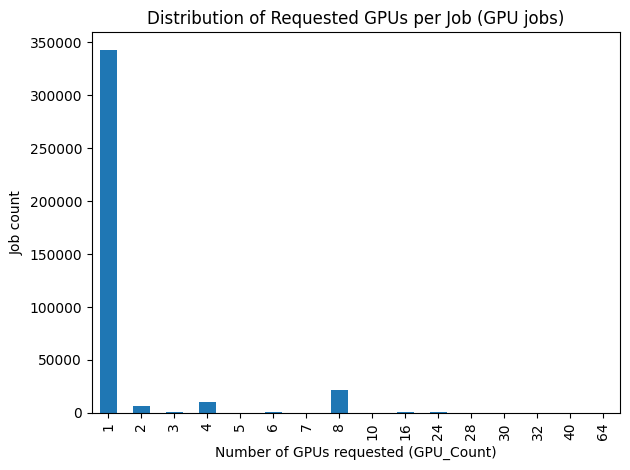


=== GPU jobs: Wait time (hours) summary ===
count    351136.000000
mean          8.811131
std          42.803429
min           0.000000
50%           0.086944
90%          24.132778
95%          48.572083
99%         112.733694
max        6865.696667
Name: WaitTimeSec, dtype: float64


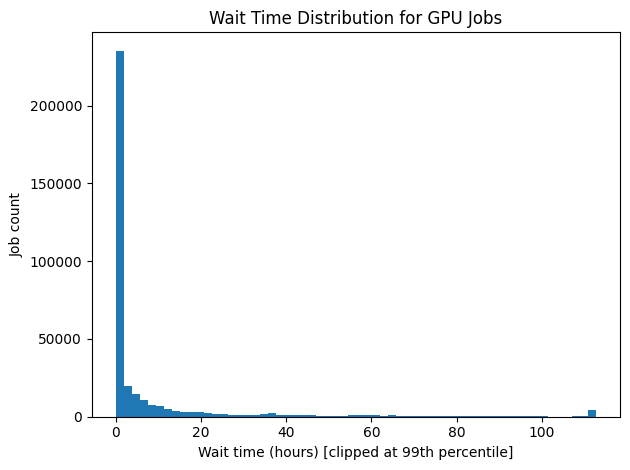

In [8]:
# Regular expression to match patterns like "gres/gpu=1"
gpu_pattern = re.compile(r"gres/gpu=([0-9]+)", re.IGNORECASE)
def extract_gpu_count(tres):
    if pd.isna(tres):
        return 0
    match = gpu_pattern.search(str(tres))
    if match:
        return int(match.group(1))
    return 0
# Create a new column indicating the number of GPUs requested
ter["GPU_Count"] = ter["ReqTRES"].apply(extract_gpu_count)

# Filter GPU jobs from the submission dataset
# A job is considered a GPU job if GPU_Count > 0.
# We create a new DataFrame sub_gpu containing only GPU jobs.
ter_gpu = ter[(ter["GPU_Count"] > 0) & (ter["GPU_Count"] <= 64)].copy()

# GPU request distribution (how many GPUs per job)
gpu_freq = ter_gpu["GPU_Count"].value_counts().sort_index()
print("\n=== GPU_Count frequency table (GPU jobs only) ===")
print(gpu_freq)
plt.figure()
gpu_freq.plot(kind="bar")
plt.xlabel("Number of GPUs requested (GPU_Count)")
plt.ylabel("Job count")
plt.title("Distribution of Requested GPUs per Job (GPU jobs)")
plt.tight_layout()
plt.show()

# Wait time distribution for GPU jobs (in hours)
# Note: WaitTimeSec is computed in your cleaning pipeline.
# We clean invalid values (inf / negative) and drop missing.
wait_gpu = ter_gpu["WaitTimeSec"].replace([np.inf, -np.inf], np.nan)
wait_gpu = wait_gpu.mask(wait_gpu < 0, np.nan).dropna()
wait_gpu_hr = wait_gpu / 3600.0
print("\n=== GPU jobs: Wait time (hours) summary ===")
print(wait_gpu_hr.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
plt.figure()
plt.hist(
    wait_gpu_hr.clip(upper=np.nanpercentile(wait_gpu_hr, 99)),
    bins=60
)
plt.xlabel("Wait time (hours) [clipped at 99th percentile]")
plt.ylabel("Job count")
plt.title("Wait Time Distribution for GPU Jobs")
plt.tight_layout()
plt.show()


## Q6. Is there a significant difference in the waiting time between tasks that use only the CPU and those that require a GPU?
#### To investigate whether there is a significant difference in waiting times between CPU-only jobs and GPU jobs, the dataset was first divided into two groups based on the number of GPUs requested in each job. Jobs with GPU_Count > 0 were classified as GPU jobs, while jobs with GPU_Count = 0 were classified as CPU-only jobs.
#### After separating the two groups, the waiting time of each job was extracted from the WaitTimeSec variable and converted into hours for easier interpretation. Invalid values such as negative waiting times or infinite values were removed during the data cleaning process.
#### Since the waiting time distribution is highly right-skewed, a log-transformation (log(1 + wait time)) was applied for visualization. Histograms were used to compare the distributions of waiting times between CPU and GPU jobs, and boxplots were used to compare their overall spread and central tendency.
#### Because the waiting time data are non-normal and contain extreme values, a non-parametric statistical test was used to compare the two groups. Specifically, the Mann–Whitney U test was applied to determine whether the distributions of waiting times for CPU-only jobs and GPU jobs differ significantly.

Number of GPU jobs: 383167
Number of CPU-only jobs: 5642159

=== GPU wait time summary (hours) ===
count    351138.000000
mean          8.811081
std          42.803312
min           0.000000
50%           0.086944
90%          24.132556
95%          48.571806
99%         112.733683
max        6865.696667
Name: WaitTimeSec, dtype: float64

=== CPU wait time summary (hours) ===
count    5.166144e+06
mean     6.827240e+00
std      3.032233e+01
min      0.000000e+00
50%      4.402778e-01
90%      1.251389e+01
95%      2.912222e+01
99%      1.165270e+02
max      1.541160e+03
Name: WaitTimeSec, dtype: float64


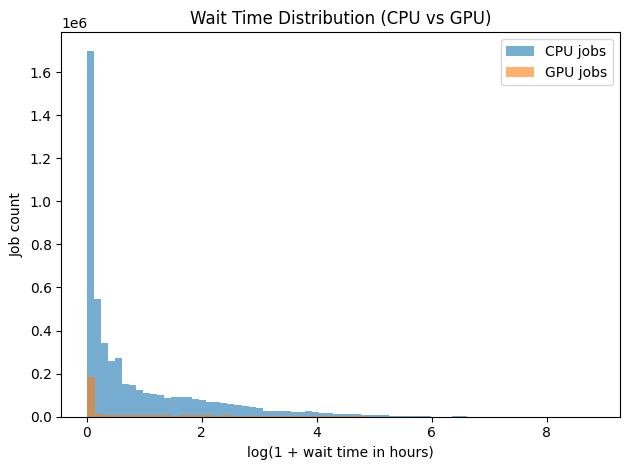

<Figure size 640x480 with 0 Axes>

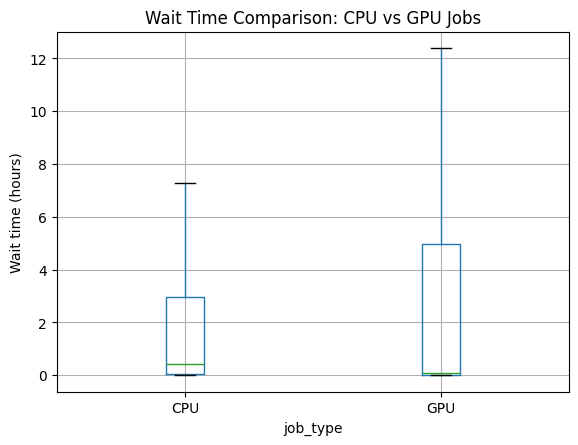


Mann–Whitney U test result
Statistic: 1054306515034.0
p-value: 0.0

Result: There is a statistically significant difference in waiting times between CPU-only jobs and GPU jobs.


In [9]:
from scipy.stats import mannwhitneyu
# Identify GPU jobs and CPU-only jobs
gpu_jobs = ter[ter["GPU_Count"] > 0].copy()
cpu_jobs = ter[ter["GPU_Count"] == 0].copy()
print("Number of GPU jobs:", len(gpu_jobs))
print("Number of CPU-only jobs:", len(cpu_jobs))

# Extract and clean wait times
wait_gpu = gpu_jobs["WaitTimeSec"].replace([np.inf, -np.inf], np.nan)
wait_gpu = wait_gpu.mask(wait_gpu < 0, np.nan).dropna()
wait_cpu = cpu_jobs["WaitTimeSec"].replace([np.inf, -np.inf], np.nan)
wait_cpu = wait_cpu.mask(wait_cpu < 0, np.nan).dropna()
# convert to hours
wait_gpu_hr = wait_gpu / 3600.0
wait_cpu_hr = wait_cpu / 3600.0

# Summary statistics
print("\n=== GPU wait time summary (hours) ===")
print(wait_gpu_hr.describe(percentiles=[0.5,0.9,0.95,0.99]))
print("\n=== CPU wait time summary (hours) ===")
print(wait_cpu_hr.describe(percentiles=[0.5,0.9,0.95,0.99]))

# Visualization (log scale due to skewness)
plt.figure()
plt.hist(np.log1p(wait_cpu_hr),
         bins=60,
         alpha=0.6,
         label="CPU jobs")
plt.hist(np.log1p(wait_gpu_hr),
         bins=60,
         alpha=0.6,
         label="GPU jobs")
plt.xlabel("log(1 + wait time in hours)")
plt.ylabel("Job count")
plt.title("Wait Time Distribution (CPU vs GPU)")
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot comparison
wait_df = pd.DataFrame({
    "wait_hr": np.concatenate([wait_cpu_hr, wait_gpu_hr]),
    "job_type": ["CPU"]*len(wait_cpu_hr) + ["GPU"]*len(wait_gpu_hr)
})
plt.figure()
wait_df.boxplot(column="wait_hr", by="job_type", showfliers=False)
plt.ylabel("Wait time (hours)")
plt.title("Wait Time Comparison: CPU vs GPU Jobs")
plt.suptitle("")
plt.show()

# Statistical test (Mann–Whitney U)
stat, p_value = mannwhitneyu(wait_cpu_hr,
                             wait_gpu_hr,
                             alternative="two-sided")
print("\nMann–Whitney U test result")
print("Statistic:", stat)
print("p-value:", p_value)

# Interpretation helper
alpha = 0.05
if p_value < alpha:
    print("\nResult: There is a statistically significant difference "
          "in waiting times between CPU-only jobs and GPU jobs.")
else:
    print("\nResult: No statistically significant difference "
          "in waiting times between CPU-only jobs and GPU jobs.")

#### The dataset contains 383,167 GPU jobs and 5,642,159 CPU-only jobs. After cleaning invalid values, the analysis included 351,138 GPU jobs and 5,166,144 CPU-only jobs with valid waiting times.

#### The summary statistics indicate that GPU jobs tend to experience longer waiting times overall. The mean waiting time for GPU jobs is 8.81 hours, compared with 6.83 hours for CPU jobs. However, both distributions are highly skewed with long right tails. For example, the median waiting time for GPU jobs is only 0.087 hours, while the median waiting time for CPU jobs is 0.44 hours, indicating that many jobs start quickly but a small number experience very long delays.

#### The histograms and boxplots further illustrate that both CPU and GPU waiting time distributions are strongly right-skewed, with GPU jobs generally showing a wider spread and more extreme waiting times. This suggests that GPU resources are more limited and may lead to longer queue times for some jobs.

#### To formally test whether the difference is statistically significant, a Mann–Whitney U test was conducted. The test returned a p-value of approximately 0, which is far below the conventional significance level of 0.05. Therefore, we reject the null hypothesis that the waiting time distributions for CPU and GPU jobs are the same.

#### Overall, the results indicate that there is a statistically significant difference in waiting times between CPU-only jobs and GPU jobs. This difference is likely due to the higher demand and limited availability of GPU resources in the cluster environment, which can lead to longer queue times for GPU-based workloads.

## Q7: A preliminary Cluster Model (for jobs with GPUs)

In [16]:
# ============================================================
# Q7: Predict GPU job waiting time category (5 classes)
# Continue from previous notebook objects
# Assumes ter_gpu has already been created
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. Minimal additional cleaning on ter_gpu
# ------------------------------------------------------------
model_gpu = ter_gpu.copy()

# keep only valid wait times
model_gpu["WaitTimeSec"] = pd.to_numeric(model_gpu["WaitTimeSec"], errors="coerce")
model_gpu = model_gpu.replace([np.inf, -np.inf], np.nan)
model_gpu = model_gpu[model_gpu["WaitTimeSec"].notna()]
model_gpu = model_gpu[model_gpu["WaitTimeSec"] >= 0].copy()

# convert wait time to hours
model_gpu["WaitTimeHr"] = model_gpu["WaitTimeSec"] / 3600.0

# submission time variables
model_gpu["Submit"] = pd.to_datetime(model_gpu["Submit"], errors="coerce")
model_gpu["SubmitHour"] = model_gpu["Submit"].dt.hour
model_gpu["SubmitWeekday"] = model_gpu["Submit"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
model_gpu["SubmitWeekday"] = pd.Categorical(
    model_gpu["SubmitWeekday"],
    categories=weekday_order,
    ordered=True
)

# ------------------------------------------------------------
# 2. Define 5 wait-time classes
# ------------------------------------------------------------
model_gpu["WaitClass"] = pd.cut(
    model_gpu["WaitTimeHr"],
    bins=[-0.001, 0.1, 1, 8, 24, np.inf],
    labels=["VeryShort", "Short", "Moderate", "Long", "VeryLong"]
)

print("=== Wait class counts ===")
print(model_gpu["WaitClass"].value_counts().sort_index())

print("\n=== Median wait time (hours) by class ===")
class_median_time = model_gpu.groupby("WaitClass", observed=False)["WaitTimeHr"].median()
print(class_median_time)

# ------------------------------------------------------------
# 3. Use only a small set of existing variables
# ------------------------------------------------------------
features_cat = ["SubmitWeekday", "SubmitHour", "Partition", "QOS"]
features_num = ["GPU_Count", "ReqCPUS", "ReqNodes", "ReqMem_MB", "TimelimitRaw", "Priority"]

# use_cols = features_cat + features_num + ["WaitClass"]
use_cols = features_cat + features_num + ["WaitClass", "WaitTimeHr"]
model_gpu = model_gpu[use_cols].copy()

X = model_gpu[features_cat + features_num]
y = model_gpu["WaitClass"]

# optional sampling to make fitting faster
sample_n = min(200000, len(model_gpu))
sample_idx = model_gpu.sample(n=sample_n, random_state=42).index
X = X.loc[sample_idx]
y = y.loc[sample_idx]

# ------------------------------------------------------------
# 4. Train / test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 5. Preprocess + multinomial logistic regression
# ------------------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)

# ------------------------------------------------------------
# 6. Evaluate classification performance
# ------------------------------------------------------------
y_pred = clf.predict(X_test)

print("\n=== Classification accuracy ===")
print(accuracy_score(y_test, y_pred))

print("\n=== Confusion matrix ===")
print(confusion_matrix(y_test, y_pred, labels=["VeryShort", "Short", "Moderate", "Long", "VeryLong"]))

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# 7. Convert predicted class to predicted waiting time
# Use class median time instead of mean
# ------------------------------------------------------------
predicted_wait_hr = pd.Series(y_pred, index=X_test.index).map(class_median_time)

result_df = X_test.copy()
result_df["TrueClass"] = y_test
result_df["PredClass"] = y_pred
result_df["PredWaitHr"] = predicted_wait_hr
result_df["TrueWaitHr"] = wait_time_hr_full.loc[result_df.index]
print("\n=== First 10 predicted results ===")
print(result_df.head(10))

=== Wait class counts ===
WaitClass
VeryShort    177293
Short         40936
Moderate      63735
Long          33914
VeryLong      35258
Name: count, dtype: int64

=== Median wait time (hours) by class ===
WaitClass
VeryShort     0.003056
Short         0.386667
Moderate      3.104167
Long         12.755417
VeryLong     48.323056
Name: WaitTimeHr, dtype: float64

=== Classification accuracy ===
0.766575

=== Confusion matrix ===
[[18789  1223   205    16    45]
 [ 2929  1382   365     5     4]
 [ 2146   245  4478   301    34]
 [  588    76   259  2699   221]
 [  407    53   122    93  3315]]

=== Classification report ===
              precision    recall  f1-score   support

        Long       0.87      0.70      0.78      3843
    Moderate       0.82      0.62      0.71      7204
       Short       0.46      0.29      0.36      4685
    VeryLong       0.92      0.83      0.87      3990
   VeryShort       0.76      0.93      0.83     20278

    accuracy                           0.77   

### Visualization

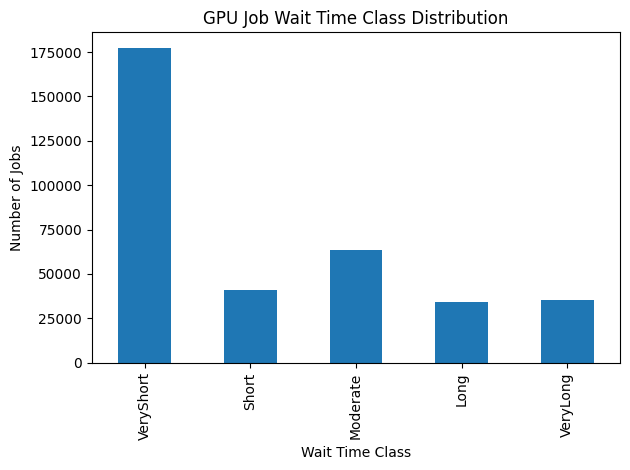

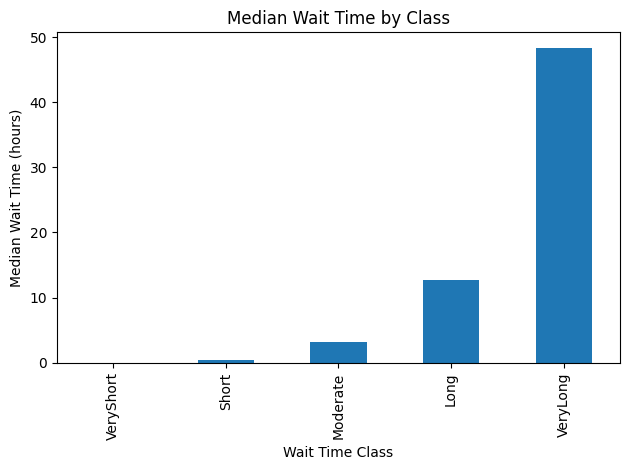

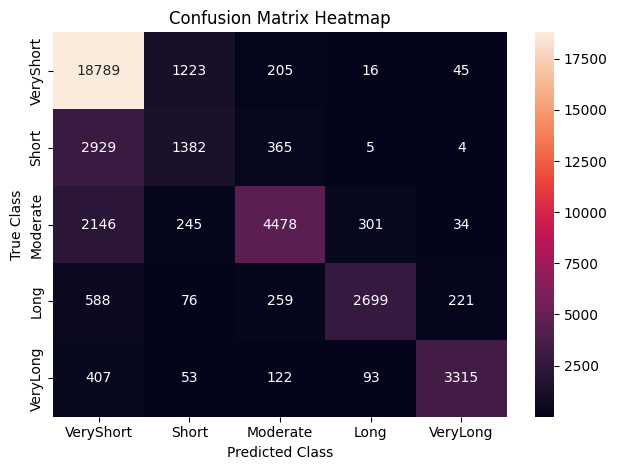

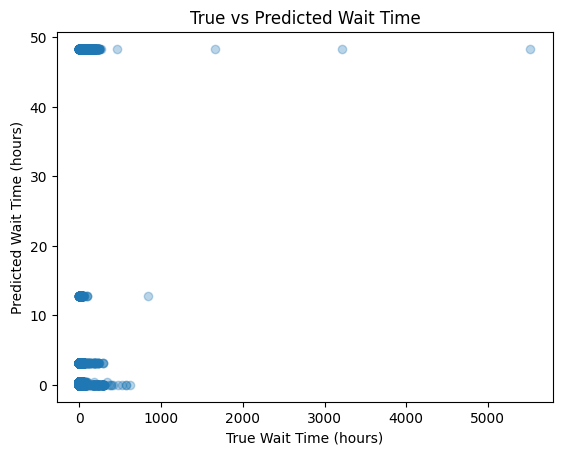

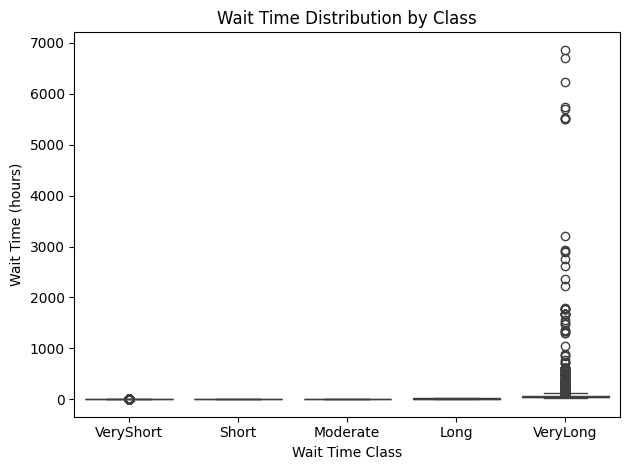

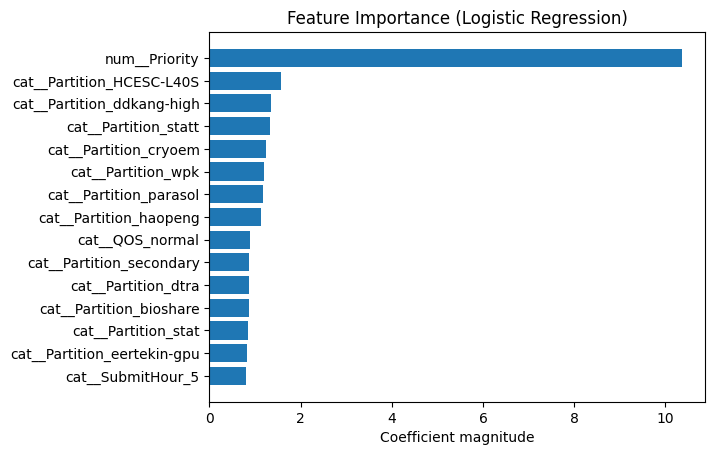

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wait class counts
plt.figure()
model_gpu["WaitClass"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Wait Time Class")
plt.ylabel("Number of Jobs")
plt.title("GPU Job Wait Time Class Distribution")
plt.tight_layout()
plt.show()



# 这个图展示每个类别代表的等待时间。
plt.figure()
class_median_time.sort_index().plot(kind="bar")
plt.xlabel("Wait Time Class")
plt.ylabel("Median Wait Time (hours)")
plt.title("Median Wait Time by Class")
plt.tight_layout()
plt.show()



# 混淆矩阵热图
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["VeryShort", "Short", "Moderate", "Long", "VeryLong"]
)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["VeryShort", "Short", "Moderate", "Long", "VeryLong"],
    yticklabels=["VeryShort", "Short", "Moderate", "Long", "VeryLong"]
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()





# 预测等待时间 vs 真实等待时间
# Add true wait time to result_df

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(result_df["TrueWaitHr"], result_df["PredWaitHr"], alpha=0.3)
plt.xlabel("True Wait Time (hours)")
plt.ylabel("Predicted Wait Time (hours)")
plt.title("True vs Predicted Wait Time")
plt.show()

# 不同类别的等待时间分布
plt.figure()
sns.boxplot(x=model_gpu["WaitClass"], y=model_gpu["WaitTimeHr"])
plt.xlabel("Wait Time Class")
plt.ylabel("Wait Time (hours)")
plt.title("Wait Time Distribution by Class")
plt.tight_layout()
plt.show()





# Feature importance / coefficient magnitude
feature_names = (
    clf.named_steps["preprocess"]
    .get_feature_names_out()
)

coef = clf.named_steps["model"].coef_

import numpy as np

importance = np.mean(np.abs(coef), axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(importance_df["Feature"][:15], importance_df["Importance"][:15])
plt.xlabel("Coefficient magnitude")
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()